In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Sab libraries load ho gayi! ✅")


Sab libraries load ho gayi! ✅


In [2]:
# Data load karo
df = pd.read_csv('../data/WA_Fn-UseC_-Telco-Customer-Churn.csv')

# Basic info dekho
print("Dataset ka size:", df.shape)
print("\nPehli 5 rows:")
df.head()

Dataset ka size: (7043, 21)

Pehli 5 rows:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
# Kitne columns hain aur unka type kya hai
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [5]:
# Koi missing values hain kya?
print("Missing values:\n", df.isnull().sum())

Missing values:
 customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [4]:
# Sabse important cheez - Churn kitna hai?
print("Churn Distribution:")
print(df['Churn'].value_counts())
print("\nPercentage:")
print(df['Churn'].value_counts(normalize=True) * 100)

Churn Distribution:
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Percentage:
Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


C:\Users\Darshan\AppData\Local\Temp\ipykernel_23580\1363576992.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Churn', data=df, palette='Set2')


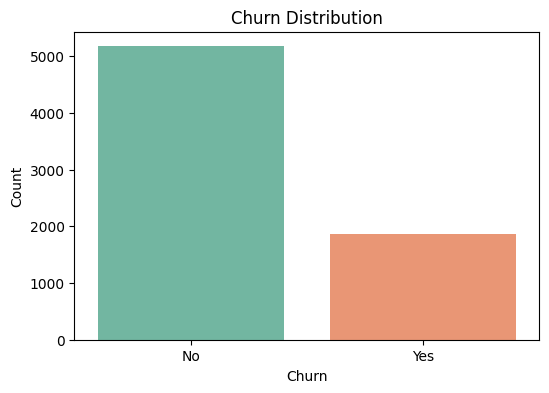

In [6]:
plt.figure(figsize=(6,4))
sns.countplot(x='Churn', data=df, palette='Set2')
plt.title('Churn Distribution')
plt.xlabel('Churn')
plt.ylabel('Count')
plt.show()

C:\Users\Darshan\AppData\Local\Temp\ipykernel_23580\2418985326.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y='MonthlyCharges', data=df, palette='Set2')


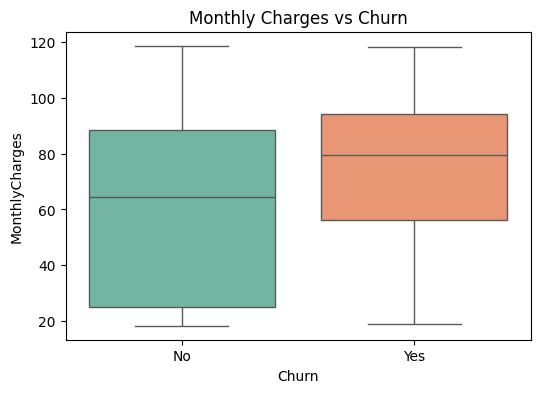

In [7]:
plt.figure(figsize=(6,4))
sns.boxplot(x='Churn', y='MonthlyCharges', data=df, palette='Set2')
plt.title('Monthly Charges vs Churn')
plt.show()

C:\Users\Darshan\AppData\Local\Temp\ipykernel_23580\3642171198.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y='tenure', data=df, palette='Set2')


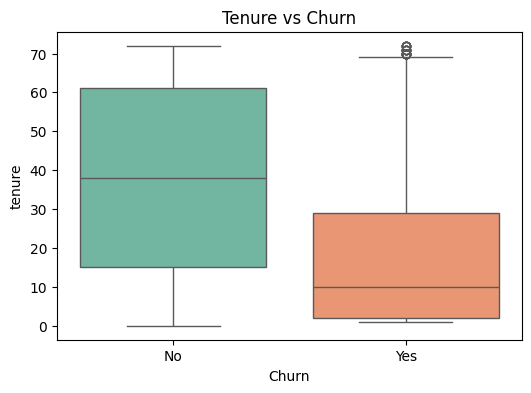

In [8]:
plt.figure(figsize=(6,4))
sns.boxplot(x='Churn', y='tenure', data=df, palette='Set2')
plt.title('Tenure vs Churn')
plt.show()

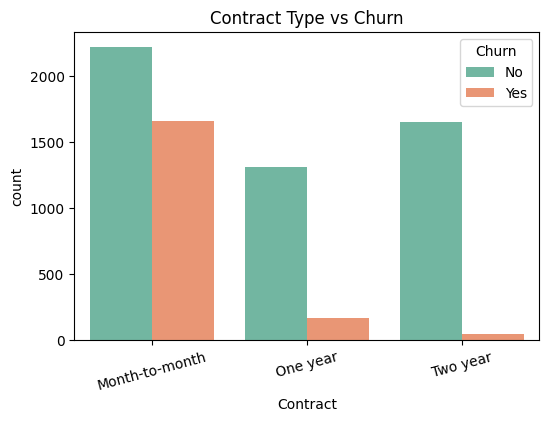

In [9]:
plt.figure(figsize=(6,4))
sns.countplot(x='Contract', hue='Churn', data=df, palette='Set2')
plt.title('Contract Type vs Churn')
plt.xticks(rotation=15)
plt.show()

In [10]:
# TotalCharges fix karo
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)
print("TotalCharges fixed! ✅")

TotalCharges fixed! ✅


C:\Users\Darshan\AppData\Local\Temp\ipykernel_23580\321717330.py:3: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)


In [11]:
# CustomerID kisi kaam ka nahi model ke liye
df.drop('customerID', axis=1, inplace=True)

print("CustomerID removed! ✅")
print("Remaining columns:", df.shape[1])

CustomerID removed! ✅
Remaining columns: 20


In [12]:
# Gender column
df['gender'] = df['gender'].map({'Male': 1, 'Female': 0})

# Baki Yes/No columns
for col in ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']:
    df[col] = df[col].map({'Yes': 1, 'No': 0})

print("Binary columns fixed! ✅")
df.head()

Binary columns fixed! ✅


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,1,Electronic check,29.85,29.85,No
1,1,0,0,0,34,1,No,DSL,Yes,No,Yes,No,No,No,One year,0,Mailed check,56.95,1889.50,No
2,1,0,0,0,2,1,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,1,Mailed check,53.85,108.15,Yes
3,1,0,0,0,45,0,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,0,Bank transfer (automatic),42.30,1840.75,No
4,0,0,0,0,2,1,No,Fiber optic,No,No,No,No,No,No,Month-to-month,1,Electronic check,70.70,151.65,Yes


In [13]:
# Baki saare text columns ko numbers mein badlo
df = pd.get_dummies(df, drop_first=True)

print("Encoding complete! ✅")
print("Final shape:", df.shape)

Encoding complete! ✅
Final shape: (7043, 31)


In [14]:
# Sab sahi hai check karo
print("Columns:", df.columns.tolist())
print("\nKoi missing values hain?", df.isnull().sum().sum())
print("\nData types:\n", df.dtypes)

Columns: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'PaperlessBilling', 'MonthlyCharges', 'TotalCharges', 'MultipleLines_No phone service', 'MultipleLines_Yes', 'InternetService_Fiber optic', 'InternetService_No', 'OnlineSecurity_No internet service', 'OnlineSecurity_Yes', 'OnlineBackup_No internet service', 'OnlineBackup_Yes', 'DeviceProtection_No internet service', 'DeviceProtection_Yes', 'TechSupport_No internet service', 'TechSupport_Yes', 'StreamingTV_No internet service', 'StreamingTV_Yes', 'StreamingMovies_No internet service', 'StreamingMovies_Yes', 'Contract_One year', 'Contract_Two year', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check', 'Churn_Yes']

Koi missing values hain? 11

Data types:
 gender                                     int64
SeniorCitizen                              int64
Partner                                    int64
Dependents                                 int64
t

In [15]:
# X = input features (jo model dekhega)
# y = output (jo model predict karega)

X = df.drop('Churn', axis=1)
y = df['Churn']

print("X shape:", X.shape)
print("y shape:", y.shape)
print("\nChurn distribution:")
print(y.value_counts())

KeyError: "['Churn'] not found in axis"

In [16]:
# Dekho Churn column ka naam kya hai ab
print(df.columns.tolist())

['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'PaperlessBilling', 'MonthlyCharges', 'TotalCharges', 'MultipleLines_No phone service', 'MultipleLines_Yes', 'InternetService_Fiber optic', 'InternetService_No', 'OnlineSecurity_No internet service', 'OnlineSecurity_Yes', 'OnlineBackup_No internet service', 'OnlineBackup_Yes', 'DeviceProtection_No internet service', 'DeviceProtection_Yes', 'TechSupport_No internet service', 'TechSupport_Yes', 'StreamingTV_No internet service', 'StreamingTV_Yes', 'StreamingMovies_No internet service', 'StreamingMovies_Yes', 'Contract_One year', 'Contract_Two year', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check', 'Churn_Yes']


In [17]:
# X = input features (jo model dekhega)
# y = output (jo model predict karega)

X = df.drop('Churn_Yes', axis=1)
y = df['Churn_Yes']

print("X shape:", X.shape)
print("y shape:", y.shape)
print("\nChurn distribution:")
print(y.value_counts())

X shape: (7043, 30)
y shape: (7043,)

Churn distribution:
Churn_Yes
False    5174
True     1869
Name: count, dtype: int64


In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("\nTraining Churn distribution:")
print(y_train.value_counts())

X_train shape: (5634, 30)
X_test shape: (1409, 30)

Training Churn distribution:
Churn_Yes
False    4138
True     1496
Name: count, dtype: int64


In [19]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

print("Before SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(y_train_balanced.value_counts())

ValueError: Input X contains NaN.
SMOTE does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

In [20]:
# Check karo X_train mein koi problem hai kya
print("X_train dtype:\n", X_train.dtypes)
print("\nKoi missing values?", X_train.isnull().sum().sum())
print("\ny_train unique values:", y_train.unique())

X_train dtype:
 gender                                     int64
SeniorCitizen                              int64
Partner                                    int64
Dependents                                 int64
tenure                                     int64
PhoneService                               int64
PaperlessBilling                           int64
MonthlyCharges                           float64
TotalCharges                             float64
MultipleLines_No phone service              bool
MultipleLines_Yes                           bool
InternetService_Fiber optic                 bool
InternetService_No                          bool
OnlineSecurity_No internet service          bool
OnlineSecurity_Yes                          bool
OnlineBackup_No internet service            bool
OnlineBackup_Yes                            bool
DeviceProtection_No internet service        bool
DeviceProtection_Yes                        bool
TechSupport_No internet service             bool
Tech

In [21]:
# Bool columns ko int mein badlo
X_train = X_train.astype(int)
X_test = X_test.astype(int)

# Missing values fill karo
X_train = X_train.fillna(X_train.median())
X_test = X_test.fillna(X_test.median())

# y_train ko 0/1 mein badlo
y_train = y_train.astype(int)
y_test = y_test.astype(int)

print("X_train missing values:", X_train.isnull().sum().sum())
print("y_train unique values:", y_train.unique())
print("Sab fix ho gaya! ✅")

IntCastingNaNError: Cannot convert non-finite values (NA or inf) to integer.Replace or remove non-finite values or cast to an integer typethat supports these values (e.g. 'Int64')

In [22]:
# Pehle missing values fill karo
X_train = X_train.fillna(False)
X_test = X_test.fillna(False)

# Ab bool ko int mein badlo
X_train = X_train.astype(int)
X_test = X_test.astype(int)

# y ko bhi fix karo
y_train = y_train.fillna(0).astype(int)
y_test = y_test.fillna(0).astype(int)

print("Missing values:", X_train.isnull().sum().sum())
print("y_train unique values:", y_train.unique())
print("Sab fix ho gaya! ✅")

Missing values: 0
y_train unique values: [0 1]
Sab fix ho gaya! ✅


In [23]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

print("Before SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(y_train_balanced.value_counts())

Before SMOTE:
Churn_Yes
0    4138
1    1496
Name: count, dtype: int64

After SMOTE:
Churn_Yes
0    4138
1    4138
Name: count, dtype: int64


In [24]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train_balanced, y_train_balanced)

print("Model training complete! ✅")

Model training complete! ✅


In [25]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred = model.predict(X_test)

print("Classification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.84      0.84      1036
           1       0.56      0.56      0.56       373

    accuracy                           0.77      1409
   macro avg       0.70      0.70      0.70      1409
weighted avg       0.77      0.77      0.77      1409


Confusion Matrix:
[[871 165]
 [165 208]]


In [26]:
import joblib

joblib.dump(model, '../model.pkl')

print("Model saved! ✅")

Model saved! ✅


In [27]:
import json

# Feature names save karo
feature_names = X_train.columns.tolist()
with open('../feature_names.json', 'w') as f:
    json.dump(feature_names, f)

print("Feature names saved! ✅")
print("Total features:", len(feature_names))

Feature names saved! ✅
Total features: 30
